### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


### ANSWERS BEGIN BELOW.

### Explore the dataset

**Look at basic stats, column names, and what the data looks like**

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("grades_crpt.csv")

In [12]:
df

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


In [13]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


In [8]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


In [15]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


**Identify anything that stands out right away**

## Check the correlations

**Use a correlation matrix to find relationships between assignments and the final exam**

I'm going to define this correlation matrix without user_id because it is the only column in the dataframe that isn't a 64-bit float and it doesn't make sense trying to find a correlation between a user_id and an assignment or final exam.

In [18]:
 # Like in our lab, we need to define the columns we wanna find correlations between. So, let's define everything.
numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


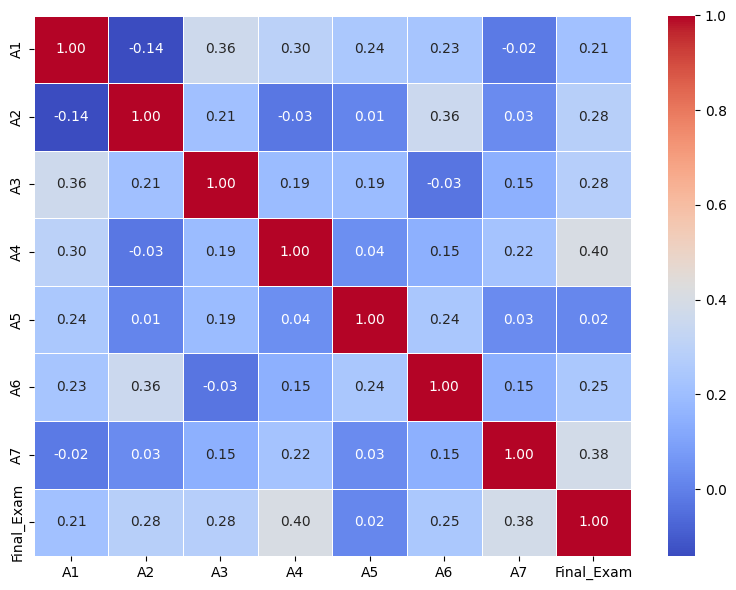

In [21]:
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

**Do any assignments seem strongly related to final exam performance?**

We need to establish that when reading a correlation matrix like the one above, the greater the (positive) number in a cell, the stronger the correlation between the row and column that form it. Therefore, we can say that A2, A3, A4 and A7 seem strongly related to the final exam performance, relative to all the possible assignments to look at. Unfortunately, none of them are *exceptionally* strongly related in a vacuum, as none of them are at least at 0.5 (which starts to read as red on the heatmap). However...

**If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

...If I had to choose only two assignment grades, I would absolutely pick **A4** and **A7**, because through this correlation matrix we see that they have the strongest positive correlation with Final_Exam by far, at 0.40 (the highest positive correlation out of the bunch not counting Final_Exam correlated to itself), and 0.38 (0.1 higher than A2 and A3, which are only 0.28) respectively.

### Check for missing values

**Which columns have them?**

As already established by using **df.info()** above (and below), I can see that every column except Final_Exam and user_id have missing values. This is because, as df.info() notes, there are 86 rows (which represent 86 students in the course), but **columns A1, A2, A3, A4, A5, A6 and A7** all have less than 86 non-null entries.

**How many are missing?**

Let's subtract!

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


In [28]:
print("A1 has: " + str(86 - 57) + " missing.")
print("A2 has: " + str(86 - 61) + " missing.")
print("A3 has: " + str(86 - 62) + " missing.")
print("A4 has: " + str(86 - 77) + " missing.")
print("A5 has: " + str(86 - 61) + " missing.")
print("A6 has: " + str(86 - 67) + " missing.")
print("A7 has: " + str(86 - 76) + " missing.")

A1 has: 29 missing.
A2 has: 25 missing.
A3 has: 24 missing.
A4 has: 9 missing.
A5 has: 25 missing.
A6 has: 19 missing.
A7 has: 10 missing.


### Handle the missing values

We'll follow all three methods from our lab, **WITHOUT REMOVING OUTLIERS FIRST** because the next section asks us to find those and try these methods again with them removed.

**Remove**

In [36]:
# Drop any rows with missing values
df_copy = df.copy()
df_remove_method = df_copy.dropna() #dropna() on its own will remove every row with a NaN value, effectively s

# Adapteed from Explore.ipynb with this week's lab
print(f"Original dataset size: {len(df)}")
print(f"After removing rows with missing values: {len(df_remove_method)}")
print(f"Rows removed: {len(df) - len(df_remove_method)}")

Original dataset size: 86
After removing rows with missing values: 13
Rows removed: 73


In [73]:
 # Like in our lab, we need to define the columns we wanna find correlations between. So, let's define everything.
numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr_matrix_remove_method = df_remove_method[numeric_cols].corr() 

print(corr_matrix_remove_method.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00  0.25  0.32  0.38  0.30  0.42  0.02        0.79
A2          0.25  1.00  0.63 -0.05 -0.20  0.31  0.00        0.29
A3          0.32  0.63  1.00 -0.01 -0.11  0.15  0.05        0.42
A4          0.38 -0.05 -0.01  1.00  0.12  0.18  0.12        0.34
A5          0.30 -0.20 -0.11  0.12  1.00  0.07 -0.14        0.14
A6          0.42  0.31  0.15  0.18  0.07  1.00 -0.18        0.34
A7          0.02  0.00  0.05  0.12 -0.14 -0.18  1.00        0.17
Final_Exam  0.79  0.29  0.42  0.34  0.14  0.34  0.17        1.00


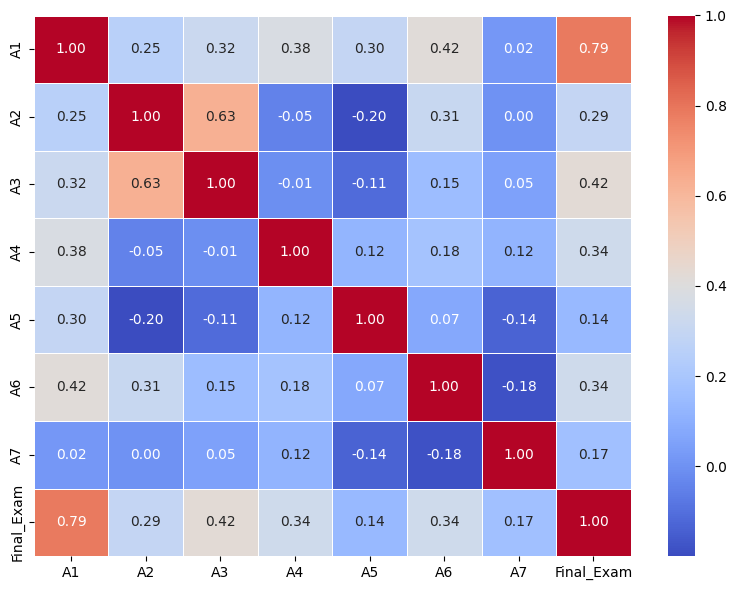

In [59]:
# Adapteed from Explore.ipynb with this week's lab
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix_remove_method, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

**Mean**

In [80]:
# Create a copy of the original dataset
df_mean_method = df.copy()

In [85]:
# We'll take this mean even with values we may want to remove later as outliers.
# Probably need to remove the other stuff first
 # Like in our lab, we need to define the columns we wanna find correlations between. So, let's define everything.
# Adapteed from Explore.ipynb with this week's lab
numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']

#We will round to one decimal place to remain conistent with the existing amount of decimal places
df_mean_method_mean = df_mean_method[numeric_cols].mean().round(1) 

print("Mean for columns is as follows:")
print(df_mean_method_mean)

Mean for columns is as follows:
A1            83.7
A2            81.1
A3            68.2
A4            82.3
A5            89.6
A6            74.4
A7            78.1
Final_Exam    55.5
dtype: float64


In [86]:
#Assign the result of the filled in matrix to the final matrix that will become our correlation matrix with the mean value used
# WITHOUT ASSIGNING THE RESULT OF fillna() TO A VARIABLE, I JUST END UP GETTING THE SAME CORR MATRIX AS THE ORIGINAL, BEFORE WE TRIED ANY MODIFICATIONS
# Adapteed from Explore.ipynb with this week's lab
df_mean = df_mean_method.fillna(df_mean_method_mean)

corr_matrix_mean_method = df_mean[numeric_cols].corr() 

print(corr_matrix_mean_method.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.11  0.27  0.27  0.15  0.17 -0.02        0.18
A2         -0.11  1.00  0.17 -0.02  0.01  0.25  0.03        0.24
A3          0.27  0.17  1.00  0.15  0.13 -0.02  0.13        0.25
A4          0.27 -0.02  0.15  1.00  0.03  0.12  0.19        0.38
A5          0.15  0.01  0.13  0.03  1.00  0.18  0.03        0.01
A6          0.17  0.25 -0.02  0.12  0.18  1.00  0.12        0.21
A7         -0.02  0.03  0.13  0.19  0.03  0.12  1.00        0.35
Final_Exam  0.18  0.24  0.25  0.38  0.01  0.21  0.35        1.00


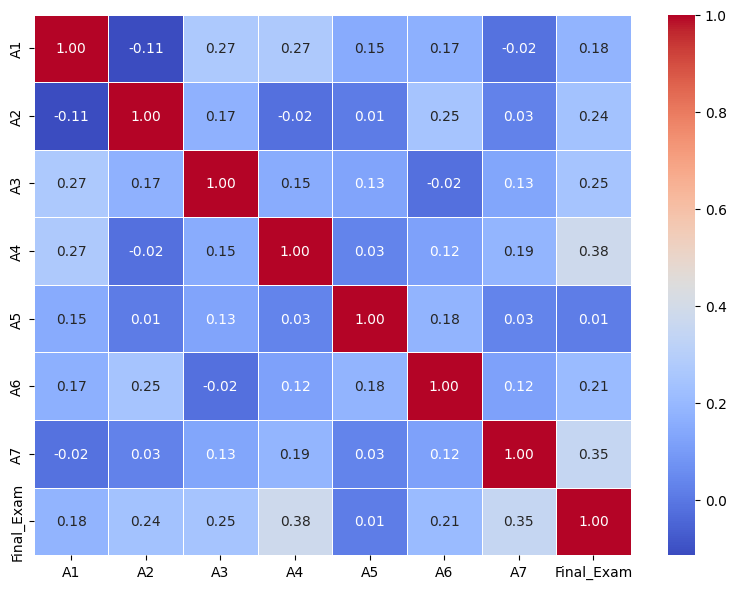

In [87]:
# Adapteed from Explore.ipynb with this week's lab
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix_mean_method, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

**Median**

In [88]:
# Like mentioned in our lab code, all we really need to do for the median is the same thing we did getting the mean, but with renamed variables.
# Create a copy of the original dataset, but without student IDs.
# If I try to perform a mean operation on the original dataset, I will get an error because I can't get a median using a string.
df_median_method = df.copy()

In [90]:
# We'll take this median even with values we may want to remove later as outliers.
 # Like in our lab, we need to define the columns we wanna find correlations between. So, let's define everything.
numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']

#We will round to one decimal place to remain conistent with the existing amount of decimal places
df_median_method_median = df_median_method[numeric_cols].median().round(1) 

print("Median for columns is as follows:")
print(df_median_method_median)

Median for columns is as follows:
A1            87.5
A2            91.1
A3            80.0
A4            87.5
A5            95.0
A6            80.0
A7            80.0
Final_Exam    56.0
dtype: float64


In [92]:
#Assign the result of the filled in matrix to the final matrix that will become our correlation matrix with the mean value used
# WITHOUT ASSIGNING THE RESULT OF fillna() TO A VARIABLE, I JUST END UP GETTING THE SAME CORR MATRIX AS THE ORIGINAL, BEFORE WE TRIED ANY MODIFICATIONS
# Adapteed from Explore.ipynb with this week's lab
df_median = df_median_method.fillna(df_median_method_median)

corr_matrix_median_method = df_median[numeric_cols].corr() 

print(corr_matrix_median_method.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.11  0.26  0.27  0.15  0.15 -0.02        0.18
A2         -0.11  1.00  0.16 -0.01 -0.00  0.24  0.03        0.22
A3          0.26  0.16  1.00  0.15  0.14  0.01  0.13        0.26
A4          0.27 -0.01  0.15  1.00  0.02  0.13  0.20        0.39
A5          0.15 -0.00  0.14  0.02  1.00  0.20  0.04        0.02
A6          0.15  0.24  0.01  0.13  0.20  1.00  0.14        0.21
A7         -0.02  0.03  0.13  0.20  0.04  0.14  1.00        0.35
Final_Exam  0.18  0.22  0.26  0.39  0.02  0.21  0.35        1.00


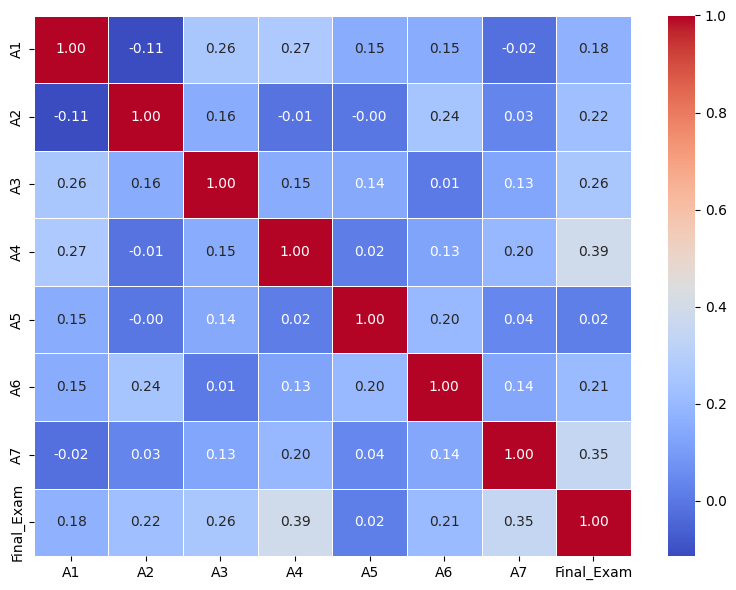

In [93]:
# Adapteed from Explore.ipynb with this week's lab
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix_median_method, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

**Which one gives you the best results? Why do you think that is?**

**If the "best results" correspond to which gives me the highest positive correlation overall, then the answer is easily the remove method**. There are several assignments where there is significantly stronger positive correlation for the remove method compared to the others I've tried (notably, A1 being 0.79 with remove and 0.18 for both mean and median).

I think this is because the removal of problematic values removes more data to work with that would lower the correlation if otherwise kept. However, from one of our readings for this week (https://www.mrdbourke.com/a-gentle-introduction-to-exploratory-data-analysis/), we recognize that more data = better. Therefore, this method might raise some eyebrows from data scientists who would want to preserve the otherwise entirely missing rows of data removed using this method.

Conversely, however, **if the "best results" correspond to which matrix is the closest to the original correlation matrix that does NOT include any changes where missing values are concerned**, then remove plummets while mean and median are strong comparative to each other. **I would give the edge to the median method** because its assignment to final grade correlations are overall closest to the original's.

The differences between the different methods' assignments-to-final exam correlation are as follows. The bolded correlations are the ones closest to the original correlations:

A1:
- Mean -> 0.21 - 0.18 = **0.03**
- Median -> 0.21 - 0.18 = **0.03**

A2:
- Mean -> 0.28 - 0.24 = **0.04**
- Median -> 0.28 - 0.22 = 0.06

A3:
- Mean -> 0.28 - 0.25 = 0.03
- Median -> 0.28 - 0.26 = **0.02**

A4:
- Mean -> 0.40 - 0.38 = 0.02
- Median -> 0.40 - 0.39 = **0.01**

A5:
- Mean -> 0.02 - 0.01 = 0.01
- Median -> 0.02 - 0.02 = **0**

A6:
- Mean -> 0.25 - 0.21 = **0.04**
- Median -> 0.25 - 0.21 = **0.04**

A7:
- Mean -> 0.38 - 0.35 = **0.03**
- Median -> 0.38 - 0.35 = **0.03**

Summing the differences between the mean method's correlations from the original correlations, the total is 0.20. 

Summing the differences between the median's method's correlations from the original correlations, the total is 0.19.

Of special note is the highest positive correlation from the original, 0.40; using the median method ends up with a value closer to it than the mean method's.

I think this result comes from the median's intrinsic resistance to outliers; we modified missing values but did not remove outliers here, which would drastically modify the calculations of the mean. Therefore, the median method's correlations were more closely kept intact

**Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?**

I came across an online version of the book: *Flexible Imputation of Missing Data*. ttps://stefvanbuuren.name/fimd/sec-evaluation.html

In chapter 2.5, it outlines four different tactics for determining how effective our imputation methods are. These include raw bias and percent bias, coverage rate, average width an root mean squared error. I think I can understand raw bias the most at my level of understanding of data science; it involves subtracting the expected value of the estimated result from the truth to get a percentage result. The closer to zero the difference is, the better, but the book says an upper limit of 5% is the limit of "acceptable performance". I think if we can **compare the results of expected values that each method of handling missing handles gives us and determine the one with the difference closest to zero, we should be able to find the most ideal method for our situation**.

This article on Medium also talks about different imputation techniques: https://medium.com/@tarangds/a-comprehensive-guide-to-data-imputation-techniques-strategies-and-best-practices-152a10fee543

The article basically claims that the best imputation techniques will probably depend on the kind of dataset we're working with; it's a case-by-case basis, with the imputation techniques I used above serving best for smaller amounts of misssing values in datasets while others like as KNN work for bigger amounts of missing values.

### Check for outliers

**Identify values that seem unrealistic or suspicious**

As mentioned around the start of my work on this assignment, my immediate thought is to single out any negative values in this dataset because it doesn't make sense to have negative points and we were not told anything about these assignments proving otherwise.

In [126]:
# Let's get rid of the non-number values.
# Then we'll single out the numbers that are negative.
#We will round to one decimal place to remain conistent with the existing amount of decimal places
df_without_str = df[numeric_cols]

#Observe that I am not checking A5, because as we have already established, there are no negative values for it.
df_without_str_negative = df_without_str[(df_without_str['A1'] < 0) | (df_without_str['A2'] < 0)
    | (df_without_str['A3'] < 0) | (df_without_str['A4'] < 0) | (df_without_str['A6'] < 0) |
    (df_without_str['A7'] < 0)]
df_without_str_negative

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
9,129.9,76.8,-5.3,93.8,100.0,90.0,12.2,65.3
12,54.2,92.9,-69.3,81.2,NaN,183.6,82.5,71.9
26,NaN,NaN,-1.7,88.8,55.0,20.0,77.5,33.1
44,-4.5,148.9,100.0,98.8,92.0,NaN,91.5,82.5
52,41.7,58.9,-70.1,88.8,80.0,70.0,71.9,31.9
67,90.0,100.0,83.0,-21.6,97.0,100.0,81.2,67.5
76,83.3,64.3,55.0,78.8,100.0,-17.0,78.8,70.9
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1


**Decide whether to keep, modify, or remove them — and explain your reasoning**

Regarding the troublesome negative scores, I would decide to **MODIFY** them with a score of 0, because that should be the minimum amount a student can get for a score. 

The same will apply to NaN values; perhaps students didn't hand in particular assignments, granting them "no" score, or maybe it was just another one of those mistakes. However, if I were to think of this as an instructor who wants to account for all of my class' students, I would say it's best to **MODIFY** the missing values with a score of 0. This way, we have scores for each assignment that makes comparison between scores throughout the dataset easier, and therefore maintain records of all students who were a part of the class in ANY capacity..

**BUT WAIT!!!!**

**What about excessively positive numbers?**

While I might question numbers with a percentage over 100, we have been told that **the values are NOT in percentage, but in points**. 

Additionally, we were not told what the maximum scores for each assignment is, and I do not want to make the assumption that the scores are all out of 100. Yes, we were told that A2, A4 and A6 offer bonus points of 15, 5 and 10 respectively, but that **still does not tell us about the maximum scores a student could get from an assignment without those bonus points**.

Therefore, I would choose to **KEEP** those excessively positive numbers, **UNLESS I was given enough information about the maximum scores to decide if these numbers over 100 are outliers or not**. If I were to remove them just because they're higher than 100, I might be getting rid of a bunch of students who score a perfect 150 on an assignment out of 150 or somesuch; it would be unfair to blot away such effort!

If these assignments were scored out of 100 though, I would use the following code to single out suspicious scores:

df_without_str_overly_positive = df[numeric_cols]

df_without_str_overly_positive = df_without_str[(df_without_str['A1'] > 100) | (df_without_str['A2'] > 115)
    | (df_without_str['A3'] > 100) | (df_without_str['A4'] > 105) | (df_without_str['A5'] > 100) | (df_without_str['A6'] > 110) |
    (df_without_str['A7'] > 100)]

**Compare the results**

 Great, so let's put all of these changes together and then compare to the previous changes we attemtped, particularly the median, which I considered to be the ideal of the three.

In [128]:
# First, replace all NaN values with 0.
df_own_method = df.copy()
df_own_method = df_own_method.fillna(0)
df_own_method

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,0.0,0.0,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,0.0,0.0,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,0.0,86.2,100.0,0.0,0.0,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,0.0,0.0,0.0,56.2,0.0,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,0.0,146.4,64.1,U083
83,79.2,0.0,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,0.0,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


In [176]:
df_own_method_copy = df_own_method[numeric_cols]

# Let's use lamba functions to change all negative values to 0.
df_own_method_copy['A1'] = df_own_method_copy['A1'].apply(lambda x: 0 if x < 0 else x)
df_own_method_copy['A2'] = df_own_method_copy['A2'].apply(lambda x: 0 if x < 0 else x)
df_own_method_copy['A3'] = df_own_method_copy['A3'].apply(lambda x: 0 if x < 0 else x)
df_own_method_copy['A4'] = df_own_method_copy['A4'].apply(lambda x: 0 if x < 0 else x)
# df_own_method_copy['A5'] = df_own_method_copy['A5'].apply(lambda x: 0 if x < 0 else x) # As we established, A5 has no negative values
df_own_method_copy['A6'] = df_own_method_copy['A6'].apply(lambda x: 0 if x < 0 else x)
df_own_method_copy['A7'] = df_own_method_copy['A7'].apply(lambda x: 0 if x < 0 else x)

# Why does the line below give me "ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all()."???
# df_own_method_copy[['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']] = df_own_method_copy[['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']].apply(lambda x: 0 if x < 0 else x)

df_own_method_copy

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
0,0.0,0.0,30.0,75.0,90.0,65.0,50.6,68.8
1,100.0,0.0,0.0,92.5,100.0,100.0,84.4,50.3
2,75.0,69.6,0.0,86.2,100.0,0.0,0.0,67.8
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
81,0.0,0.0,0.0,56.2,0.0,29.2,60.0,57.5
82,87.5,0.0,70.0,174.8,91.0,0.0,146.4,64.1
83,79.2,0.0,60.0,27.5,50.0,60.0,75.0,45.6
84,0.0,0.0,85.0,100.0,55.0,0.0,0.0,30.6


In [177]:
corr_matrix_own_method = df_own_method_copy[numeric_cols].corr() 

print(corr_matrix_own_method.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00  0.15  0.25  0.19 -0.05  0.13 -0.11        0.14
A2          0.15  1.00  0.25  0.02  0.12  0.09 -0.07        0.18
A3          0.25  0.25  1.00  0.06 -0.06 -0.15  0.06        0.14
A4          0.19  0.02  0.06  1.00  0.15  0.00  0.09        0.20
A5         -0.05  0.12 -0.06  0.15  1.00  0.07 -0.02       -0.03
A6          0.13  0.09 -0.15  0.00  0.07  1.00  0.01        0.14
A7         -0.11 -0.07  0.06  0.09 -0.02  0.01  1.00        0.29
Final_Exam  0.14  0.18  0.14  0.20 -0.03  0.14  0.29        1.00


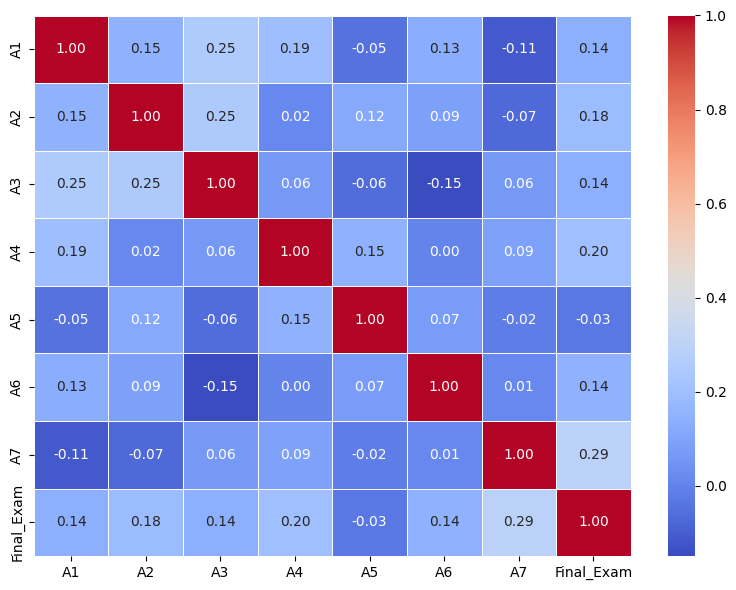

In [178]:
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix_own_method, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

Overll, the correlations resulting from my own method are significantly less positively correlated than using any of the remove, mean or median methods. 

For completeness, the differences of the assignment-final exam correlations of the correlation matrixes without and with cleaning through mean, median an my own method are as follows:

A1:
- Mean -> 0.21 - 0.18 = **0.03**
- Median -> 0.21 - 0.18 = **0.03**
- Own Method -> 0.21 - 0.14 = 0.07
  
A2:
- Mean -> 0.28 - 0.24 = **0.04**
- Median -> 0.28 - 0.22 = 0.06
- Own Method -> 0.28 - 0.18 = 0.10
  
A3:
- Mean -> 0.28 - 0.25 = 0.03
- Median -> 0.28 - 0.26 = **0.02**
- Own Method -> 0.28 - 0.14 = 0.14
  
A4:
- Mean -> 0.40 - 0.38 = 0.02
- Median -> 0.40 - 0.39 = **0.01**
- Own Method -> 0.40 - 0.20 = 0.20
  
A5:
- Mean -> 0.02 - 0.01 = 0.01
- Median -> 0.02 - 0.02 = **0**
- Own Method -> 0.02 - -0.03 = 0.05
  
A6:
- Mean -> 0.25 - 0.21 = **0.04**
- Median -> 0.25 - 0.21 = **0.04**
- Own Method -> 0.25 - 0.29 = **-0.04**
  
A7:
- Mean -> 0.38 - 0.35 = **0.03**
- Median -> 0.38 - 0.35 = **0.03**
- Own Method -> 0.38 - 0.29 = 0.09

It looks like my own method's correlations are drastically different from using either the mean or median only. Interestingly, the correlation to A6 is the same as mean and median, but on the opposite sides (positive, negative). 

I think these differences came about because the decision to convert suspicious values to 0 is a very big shift in the overall variety of numbers. Because every student had their final exam scores accounted for but there were many instances of missing scores alone, I think it makes sense that the correlations weren't as positive than mean and median, which replaced missing values with higher numbers (note that the mean for the final exam is a score of ~55, which is very far from 0). With the removal method getting rid of problematic missing values entirely, it skips these problems entirely, with the caveat of a signficantly smaller dataset size.